# Satellite Collision Risk Classification
## Modeling and Validation

### Objective
In this notebook, we train and compare four classification models for satellite collision risk level prediction:

1. Logistic Regression
2. Random Forest
3. XGBoost
4. Deep Neural Network

### Target Classes
We predict three classes:

- **0 = Low Risk**
- **1 = Medium Risk**
- **2 = High Risk**

### Why this notebook is structured this way
To ensure reproducibility and fair comparison:

- all common experiment settings are centralized
- each model has its own dedicated hyperparameters
- all models use the same train/validation split
- all models are evaluated using the same metrics

### Evaluation Metrics
We compare models using:

- Accuracy
- Macro Precision
- Macro Recall
- Macro F1
- Confusion Matrix
- Classification Report

In [1]:
!pip install -q pandas numpy scikit-learn matplotlib seaborn xgboost torch

# 1. Imports
We first import all required packages for data loading, modeling, evaluation, visualization, and neural network training.

In [2]:
import os
import json
import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    f1_score
)

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

pd.set_option("display.max_columns", 200)
pd.set_option("display.float_format", "{:.4f}".format)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (7, 4)

# 2. Centralized Configuration
We define all experiment settings in one place.

This includes:
- global settings shared across all models
- model-specific hyperparameters

In [3]:
CONFIG = {
    "global": {
        "seed": 42,
        "target_col": "risk_label",
        "continuous_target_col": "risk",
        "label_names": ["Low", "Medium", "High"],
        "device": "cuda" if torch.cuda.is_available() else "cpu",
        "results_path": "/content/model_comparison_results.csv",
        "predictions_path": "/content/test_predictions.csv"
    },

    "logreg": {
        "max_iter": 2000,
        "class_weight": "balanced",
        "solver": "lbfgs",
        "multi_class": "multinomial"
    },

    "rf": {
        "n_estimators": 300,
        "max_depth": 12,
        "min_samples_split": 5,
        "min_samples_leaf": 2,
        "class_weight": "balanced",
        "n_jobs": -1
    },

    "xgb": {
        "objective": "multi:softmax",
        "num_class": 3,
        "n_estimators": 300,
        "max_depth": 6,
        "learning_rate": 0.05,
        "subsample": 0.9,
        "colsample_bytree": 0.9,
        "eval_metric": "mlogloss"
    },

    "dnn": {
        "batch_size": 256,
        "epochs": 20,
        "learning_rate": 0.0005,
        "hidden_1": 256,
        "hidden_2": 128,
        "hidden_3": 64,
        "dropout_1": 0.30,
        "dropout_2": 0.30,
        "dropout_3": 0.20
    }
}

# 3. Reproducibility Setup
We set all random seeds so that model behavior is as reproducible as possible.

In [4]:
def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(CONFIG["global"]["seed"])

SEED = CONFIG["global"]["seed"]
TARGET_COL = CONFIG["global"]["target_col"]
CONT_TARGET_COL = CONFIG["global"]["continuous_target_col"]
LABEL_NAMES = CONFIG["global"]["label_names"]
DEVICE = CONFIG["global"]["device"]

print("Seed:", SEED)
print("Device:", DEVICE)

Seed: 42
Device: cuda


# 4. Load Feature-Engineered Datasets
We load the processed train, validation, and test files prepared in earlier parts of the pipeline.

In [5]:
train_df = pd.read_csv("/content/train_featured.csv")
val_df   = pd.read_csv("/content/val_featured.csv")
test_df  = pd.read_csv("/content/test_featured.csv")

print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)
print("Test shape:", test_df.shape)

train_df.head()

Train shape: (130596, 147)
Validation shape: (32038, 147)
Test shape: (24484, 145)


,time_to_tca,max_risk_estimate,max_risk_scaling,miss_distance,relative_speed,relative_position_r,relative_position_t,relative_position_n,relative_velocity_r,relative_velocity_t,relative_velocity_n,t_time_lastob_start,t_time_lastob_end,t_recommended_od_span,t_actual_od_span,t_obs_available,t_obs_used,t_residuals_accepted,t_weighted_rms,t_rcs_estimate,t_cd_area_over_mass,t_cr_area_over_mass,t_sedr,t_j2k_sma,t_j2k_ecc,t_j2k_inc,t_ct_r,t_cn_r,t_cn_t,t_crdot_r,t_crdot_t,t_crdot_n,t_ctdot_r,t_ctdot_t,t_ctdot_n,t_ctdot_rdot,t_cndot_r,t_cndot_t,t_cndot_n,t_cndot_rdot,t_cndot_tdot,c_time_lastob_start,c_time_lastob_end,c_recommended_od_span,c_actual_od_span,c_obs_available,c_obs_used,c_residuals_accepted,c_weighted_rms,c_rcs_estimate,c_cd_area_over_mass,c_cr_area_over_mass,c_sedr,c_j2k_sma,c_j2k_ecc,c_j2k_inc,c_ct_r,c_cn_r,c_cn_t,c_crdot_r,c_crdot_t,c_crdot_n,c_ctdot_r,c_ctdot_t,c_ctdot_n,c_ctdot_rdot,c_cndot_r,c_cndot_t,c_cndot_n,c_cndot_rdot,c_cndot_tdot,t_span,c_span,t_h_apo,t_h_per,c_h_apo,c_h_per,geocentric_latitude,azimuth,elevation,mahalanobis_distance,t_position_covariance_det,c_position_covariance_det,t_sigma_r,c_sigma_r,t_sigma_t,c_sigma_t,t_sigma_n,c_sigma_n,t_sigma_rdot,c_sigma_rdot,t_sigma_tdot,c_sigma_tdot,t_sigma_ndot,c_sigma_ndot,F10,F3M,SSN,AP,flag_c_rcs_missing,flag_t_rcs_missing,flag_cov_block_missing,flag_solar_missing,obj_DEBRIS,obj_PAYLOAD,obj_ROCKET BODY,obj_TBA,obj_UNKNOWN,rel_pos_mag,rel_vel_mag,miss_per_speed,pos_r_over_t,delta_sma,delta_sma_abs,delta_ecc,delta_ecc_abs,delta_inc,delta_inc_abs,delta_h_apo,delta_h_per,ecc_product,combined_rcs,rcs_ratio,combined_cd_area,combined_cr_area,combined_sigma_r,combined_sigma_t,combined_sigma_n,total_pos_uncertainty,miss_over_sigma,cov_det_ratio,combined_sigma_rdot,combined_sigma_tdot,combined_sigma_ndot,t_obs_usage_ratio,c_obs_usage_ratio,t_od_span_ratio,t_obs_freshness,c_obs_freshness,risk_estimate_gap,sigma_r_per_tca,miss_per_tca,mahal_over_miss,solar_activity,solar_pressure,risk,risk_label
0,0.9228,-0.6695,-0.6239,-0.4871,-1.2650,0.1866,0.2019,-0.0443,0.5471,0.8905,-0.3073,0.0000,0.0000,0.6064,0.7609,-0.2152,-0.1388,-0.4290,1.3959,-0.7538,0.0922,-0.8371,0.6148,-0.6094,-0.3424,-0.0200,-0.1609,-0.0179,-0.3129,0.0716,-0.1292,0.2737,0.0608,0.2640,0.0523,-0.1272,-0.9054,-1.1359,0.7625,1.2131,0.9167,0.0000,0.0000,-0.8340,-0.8116,0.0936,0.0970,0.3555,-0.6844,-2.0564,-0.5538,-0.7304,8.5146,-1.2931,1.9013,-0.2042,-0.9772,-0.0235,2.9182,1.0770,-0.0962,-3.2401,0.8067,2.8446,0.5680,-2.8187,-1.4483,4.5096,-0.2382,-4.4844,1.5817,-0.7714,0.0000,-0.7117,-0.5755,-0.6590,-1.7465,-0.3465,-1.0289,-1.5561,-1.2315,0.8356,0.9486,0.3798,-0.0281,0.6176,1.1404,1.2908,0.1366,1.1900,1.5105,0.5361,2.0666,0.5885,-0.1498,-0.0945,1.2038,-0.4483,-0.6667,0,0,0,0,1,0,0,0,0,-0.4872,-1.2651,-0.3032,0.3846,3.3067,1.0494,-1.9796,2.0318,0.5245,0.1755,0.3510,5.0704,0.7260,-1.9214,-0.3482,-0.5533,-0.7736,-0.0533,1.1061,0.1103,1.1093,-0.6434,-0.0010,1.4786,1.9373,-0.1393,0.0034,0.0000,0.0000,0.9225,0.4032,0.0949,-0.2655,-0.4594,-0.4397,-0.4120,-0.5642,-7.5613,2
1,0.6457,-0.8244,-0.3978,-0.4291,-1.2650,0.2325,0.3027,-0.0647,0.5225,0.8905,-0.3073,0.0000,0.0000,0.2972,0.4348,-0.1421,-0.0736,-0.2859,1.3959,-0.7538,0.2417,-0.3762,0.5795,-0.6094,-0.3431,-0.0200,-0.1243,0.2633,0.1563,0.0281,-0.1100,-0.3002,0.1325,0.2071,-0.2465,-0.0676,-0.3172,-0.2486,0.7717,0.2174,0.3197,0.0000,0.0000,-0.8340,-0.8116,0.1794,0.1858,0.3555,-0.6330,-2.0564,-0.5557,-0.7304,7.9166,-1.2931,1.9018,-0.2042,-1.0880,-0.2327,2.6546,1.1988,-0.0962,-2.9498,0.2081,2.8437,0.5391,-2.8178,-1.2799,4.0146,-0.1489,-3.9923,1.4046,-0.7714,0.0000,-0.7119,-0.5754,-0.6588,-1.7466,-0.3465,-1.0289,-1.4846,-1.0133,0.7033,0.3784,0.2726,0.0581,0.5374,1.0324,1.1010,0.0270,0.9733,1.3622,0.3886,1.6598,0.2576,-0.2107,-0.1903,1.1243,0.0000,1.3333,0,0,0,0,1,0,0,0,0,-0.4291,-1.2651,-0.1112,0.3486,3.3067,1.0494,-1.9803,2.0325,0.5245,0.1755,0.3504,5.0711,0.7246,-1.9214,-0.3482,-0.5528,-0.7551,0.0320,0.9989,0.0007,1.0018,-0.6273,-0.0000,1.3334,1.5557,-0.1963,0.0171,0.0000

# 5. Load Threshold Metadata
We load the saved label thresholds for completeness and experiment traceability.

In [6]:
with open("/content/label_thresholds.json", "r") as f:
    thresholds = json.load(f)

print("Loaded thresholds:")
print(thresholds)

Loaded thresholds:
{'q50': -17.890084136976203, 'q80': -8.098923284273745}


# 5A. Clean Infinite and Extreme Values

Some engineered ratio-based features can create:

- `inf`
- `-inf`
- new `NaN` values after division
- extremely large values

Before modeling, we replace infinities with missing values, then fill them using
training-set medians only so the train/validation/test pipeline remains consistent.

In [7]:
def replace_inf_with_nan(df):
    df = df.copy()
    return df.replace([np.inf, -np.inf], np.nan)

train_df = replace_inf_with_nan(train_df)
val_df   = replace_inf_with_nan(val_df)
test_df  = replace_inf_with_nan(test_df)

numeric_cols_train = train_df.select_dtypes(include=[np.number]).columns
train_medians = train_df[numeric_cols_train].median()

train_df[numeric_cols_train] = train_df[numeric_cols_train].fillna(train_medians)

common_val_cols = [c for c in numeric_cols_train if c in val_df.columns]
val_df[common_val_cols] = val_df[common_val_cols].fillna(train_medians[common_val_cols])

common_test_cols = [c for c in numeric_cols_train if c in test_df.columns]
test_df[common_test_cols] = test_df[common_test_cols].fillna(train_medians[common_test_cols])

print("Inf/-Inf replacement and median filling complete.")

Inf/-Inf replacement and median filling complete.


# 5B. Sanity Check for Finite Values

We verify that all numeric columns are now finite before splitting features and labels.

In [8]:
def check_finite_df(df, name):
    arr = df.select_dtypes(include=[np.number]).to_numpy()
    print(f"{name} -> all finite: {np.isfinite(arr).all()}")
    print(f"{name} -> inf count : {np.isinf(arr).sum()}")
    print(f"{name} -> nan count : {np.isnan(arr).sum()}")

check_finite_df(train_df, "train_df")
check_finite_df(val_df, "val_df")
check_finite_df(test_df, "test_df")

train_df -> all finite: True
train_df -> inf count : 0
train_df -> nan count : 0
val_df -> all finite: True
val_df -> inf count : 0
val_df -> nan count : 0
test_df -> all finite: True
test_df -> inf count : 0
test_df -> nan count : 0


# 6. Separate Features and Target
We use:

- `risk_label` as the multiclass target
- `risk` is dropped from features because it is the original continuous target source

In [9]:
drop_cols_train = [c for c in [TARGET_COL, CONT_TARGET_COL] if c in train_df.columns]
drop_cols_val   = [c for c in [TARGET_COL, CONT_TARGET_COL] if c in val_df.columns]
drop_cols_test  = [c for c in [TARGET_COL, CONT_TARGET_COL] if c in test_df.columns]

X_train = train_df.drop(columns=drop_cols_train).copy()
y_train = train_df[TARGET_COL].astype(int).copy()

X_val = val_df.drop(columns=drop_cols_val).copy()
y_val = val_df[TARGET_COL].astype(int).copy()

X_test = test_df.drop(columns=drop_cols_test).copy()

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_val:", X_val.shape)
print("y_val:", y_val.shape)
print("X_test:", X_test.shape)

X_train: (130596, 145)
y_train: (130596,)
X_val: (32038, 145)
y_val: (32038,)
X_test: (24484, 145)


# 6A. Debug Model Input Matrix

We inspect the actual feature matrices used by the models to find:
- non-finite values
- extremely large values
- unexpected dtypes

In [10]:
print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)
print("X_test shape:", X_test.shape)

print("\nDtypes in X_train:")
print(X_train.dtypes.value_counts())

X_train shape: (130596, 145)
X_val shape: (32038, 145)
X_test shape: (24484, 145)

Dtypes in X_train:
float64    136
int64        9
Name: count, dtype: int64


In [11]:
def inspect_matrix(X, name):
    arr = X.to_numpy()
    print(f"\n{name}")
    print("-" * 50)
    print("all finite:", np.isfinite(arr).all())
    print("inf count:", np.isinf(arr).sum())
    print("nan count:", np.isnan(arr).sum())
    print("max abs value:", np.nanmax(np.abs(arr)))

inspect_matrix(X_train, "X_train")
inspect_matrix(X_val, "X_val")
inspect_matrix(X_test, "X_test")


X_train
--------------------------------------------------
all finite: True
inf count: 0
nan count: 0
max abs value: 3.4160443715413837e+50

X_val
--------------------------------------------------
all finite: True
inf count: 0
nan count: 0
max abs value: 2.4574046788091067e+50

X_test
--------------------------------------------------
all finite: True
inf count: 0
nan count: 0
max abs value: 1.0626937475627636e+48


In [12]:
FLOAT32_MAX = np.finfo(np.float32).max
print("float32 max:", FLOAT32_MAX)

float32 max: 3.4028235e+38


In [13]:
# Find columns with non-finite or too-large values
bad_cols = []

for col in X_train.columns:
    vals = pd.to_numeric(X_train[col], errors="coerce").to_numpy()

    if np.isnan(vals).any() or np.isinf(vals).any() or (np.abs(vals) > FLOAT32_MAX).any():
        bad_cols.append(col)

print("Columns with issues:")
print(bad_cols)

Columns with issues:
['cov_det_ratio']


In [14]:
# Show detailed stats for bad columns
for col in bad_cols:
    vals = pd.to_numeric(X_train[col], errors="coerce")
    print(f"\nColumn: {col}")
    print("dtype:", X_train[col].dtype)
    print("nan count:", vals.isna().sum())
    print("inf count:", np.isinf(vals).sum())
    print("max abs:", np.nanmax(np.abs(vals.to_numpy())))
    print("min:", vals.min())
    print("max:", vals.max())


Column: cov_det_ratio
dtype: float64
nan count: 0
inf count: 0
max abs: 3.4160443715413837e+50
min: -0.0421402867627035
max: 3.4160443715413837e+50


# 6B. Fix Extreme Values in cov_det_ratio

The engineered feature `cov_det_ratio` contains extremely large finite values caused by division with near-zero denominators.

We clip this feature to a safe range for stable model training.

In [15]:
SAFE_LIMIT = 1e6

for df in [X_train, X_val, X_test]:
    if "cov_det_ratio" in df.columns:
        df["cov_det_ratio"] = df["cov_det_ratio"].clip(
            lower=-SAFE_LIMIT,
            upper=SAFE_LIMIT
        )

print("cov_det_ratio clipped successfully.")

cov_det_ratio clipped successfully.


In [16]:
for name, df in zip(
    ["X_train", "X_val", "X_test"],
    [X_train, X_val, X_test]
):
    print(name, df["cov_det_ratio"].min(), df["cov_det_ratio"].max())

X_train -0.0421402867627035 1000000.0
X_val -0.0058009937344139 1000000.0
X_test -0.0058009937344139 1000000.0


# 6C. Remove Potential Target-Proxy Features

Some features appear to be very closely tied to the original risk-generation process, such as
`max_risk_estimate`, `max_risk_scaling`, and the engineered `risk_estimate_gap`.

To reduce the chance of target leakage or overly optimistic performance, we remove these columns
before final model training and comparison.

In [17]:
proxy_cols = [
    "max_risk_estimate",
    "max_risk_scaling",
    "risk_estimate_gap"
]

proxy_cols_present_train = [c for c in proxy_cols if c in X_train.columns]
proxy_cols_present_val   = [c for c in proxy_cols if c in X_val.columns]
proxy_cols_present_test  = [c for c in proxy_cols if c in X_test.columns]

print("Removing proxy columns from X_train:", proxy_cols_present_train)
print("Removing proxy columns from X_val:  ", proxy_cols_present_val)
print("Removing proxy columns from X_test: ", proxy_cols_present_test)

X_train = X_train.drop(columns=proxy_cols_present_train)
X_val   = X_val.drop(columns=proxy_cols_present_val)
X_test  = X_test.drop(columns=proxy_cols_present_test)

print("\nShapes after proxy-column removal:")
print("X_train:", X_train.shape)
print("X_val:  ", X_val.shape)
print("X_test: ", X_test.shape)

Removing proxy columns from X_train: ['max_risk_estimate', 'max_risk_scaling', 'risk_estimate_gap']
Removing proxy columns from X_val:   ['max_risk_estimate', 'max_risk_scaling', 'risk_estimate_gap']
Removing proxy columns from X_test:  ['max_risk_estimate', 'max_risk_scaling', 'risk_estimate_gap']

Shapes after proxy-column removal:
X_train: (130596, 142)
X_val:   (32038, 142)
X_test:  (24484, 142)


# 7. Class Distribution Check
We inspect the balance of the three risk classes in the train and validation sets.

In [18]:
def print_class_distribution(y, name):
    counts = pd.Series(y).value_counts().sort_index()
    props = pd.Series(y).value_counts(normalize=True).sort_index()

    print(f"\n{name} distribution:")
    for cls in counts.index:
        print(f"Class {cls} ({LABEL_NAMES[cls]}): {counts[cls]:,} rows ({props[cls]*100:.2f}%)")

print_class_distribution(y_train, "Train")
print_class_distribution(y_val, "Validation")


Train distribution:
Class 0 (Low): 65,299 rows (50.00%)
Class 1 (Medium): 39,179 rows (30.00%)
Class 2 (High): 26,118 rows (20.00%)

Validation distribution:
Class 0 (Low): 15,982 rows (49.88%)
Class 1 (Medium): 9,638 rows (30.08%)
Class 2 (High): 6,418 rows (20.03%)


# 8. Common Evaluation Functions
These reusable helper functions ensure that all models are evaluated in a consistent way.

In [19]:
def evaluate_predictions(model_name, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )

    return {
        "Model": model_name,
        "Accuracy": acc,
        "Macro Precision": precision,
        "Macro Recall": recall,
        "Macro F1": f1
    }

def print_model_report(model_name, y_true, y_pred):
    print(f"\n{'='*70}")
    print(f"{model_name} - Classification Report")
    print(f"{'='*70}")
    print(classification_report(y_true, y_pred, target_names=LABEL_NAMES, zero_division=0))

def plot_confusion(model_name, y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(5, 4))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=LABEL_NAMES,
        yticklabels=LABEL_NAMES
    )
    plt.title(f"{model_name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()

# 9. Logistic Regression
We begin with an interpretable linear baseline.

{'Model': 'Logistic Regression', 'Accuracy': 0.4988451214183158, 'Macro Precision': 0.1662817071394386, 'Macro Recall': 0.3333333333333333, 'Macro F1': 0.2218797723170901}

Logistic Regression - Classification Report
              precision    recall  f1-score   support

         Low       0.50      1.00      0.67     15982
      Medium       0.00      0.00      0.00      9638
        High       0.00      0.00      0.00      6418

    accuracy                           0.50     32038
   macro avg       0.17      0.33      0.22     32038
weighted avg       0.25      0.50      0.33     32038



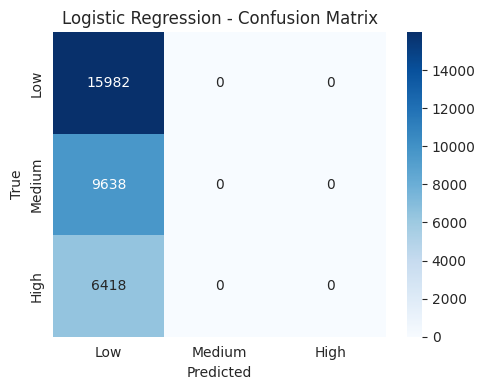

In [20]:
logreg_model = LogisticRegression(
    **CONFIG["logreg"],
    random_state=SEED
)

logreg_model.fit(X_train, y_train)
logreg_val_pred = logreg_model.predict(X_val)

logreg_results = evaluate_predictions("Logistic Regression", y_val, logreg_val_pred)
print(logreg_results)
print_model_report("Logistic Regression", y_val, logreg_val_pred)
plot_confusion("Logistic Regression", y_val, logreg_val_pred)

Logistic Regression performs poorly and predicts almost all samples as the Low Risk class. This is reflected in the confusion matrix, where Medium and High Risk events are rarely identified correctly. The result suggests that a linear decision boundary is too simple for this dataset and cannot capture the nonlinear relationships present in the engineered orbital and uncertainty features.

# 10. Random Forest
Random Forest is a nonlinear ensemble model well suited to structured tabular data.

{'Model': 'Random Forest', 'Accuracy': 0.7902802921530683, 'Macro Precision': 0.7560448041604569, 'Macro Recall': 0.7779244785625824, 'Macro F1': 0.7631378813581543}

Random Forest - Classification Report
              precision    recall  f1-score   support

         Low       0.95      0.85      0.90     15982
      Medium       0.68      0.68      0.68      9638
        High       0.64      0.80      0.71      6418

    accuracy                           0.79     32038
   macro avg       0.76      0.78      0.76     32038
weighted avg       0.81      0.79      0.79     32038



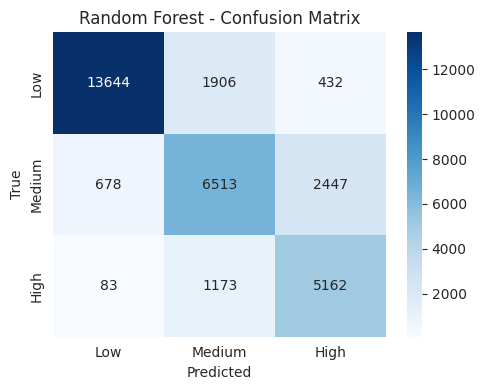

In [21]:
rf_model = RandomForestClassifier(
    **CONFIG["rf"],
    random_state=SEED
)

rf_model.fit(X_train, y_train)
rf_val_pred = rf_model.predict(X_val)

rf_results = evaluate_predictions("Random Forest", y_val, rf_val_pred)
print(rf_results)
print_model_report("Random Forest", y_val, rf_val_pred)
plot_confusion("Random Forest", y_val, rf_val_pred)

Random Forest shows a strong improvement over Logistic Regression and is able to classify all three risk levels reasonably well. The confusion matrix indicates that most Low Risk events are identified correctly, while some confusion remains between Medium and High Risk classes. This suggests that tree-based nonlinear splits are much better suited for the structure of the collision-risk dataset.

# 11. XGBoost
XGBoost is typically one of the strongest models for engineered tabular features.

{'Model': 'XGBoost', 'Accuracy': 0.8963106311255384, 'Macro Precision': 0.8797922845089117, 'Macro Recall': 0.8823273476598451, 'Macro F1': 0.880894446935181}

XGBoost - Classification Report
              precision    recall  f1-score   support

         Low       0.96      0.94      0.95     15982
      Medium       0.82      0.85      0.84      9638
        High       0.86      0.85      0.86      6418

    accuracy                           0.90     32038
   macro avg       0.88      0.88      0.88     32038
weighted avg       0.90      0.90      0.90     32038



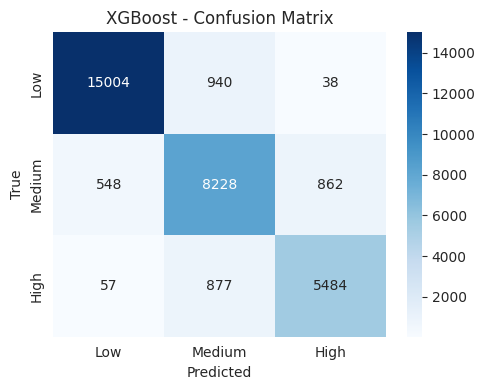

In [22]:
xgb_model = XGBClassifier(
    **CONFIG["xgb"],
    random_state=SEED
)

xgb_model.fit(X_train, y_train)
xgb_val_pred = xgb_model.predict(X_val)

xgb_results = evaluate_predictions("XGBoost", y_val, xgb_val_pred)
print(xgb_results)
print_model_report("XGBoost", y_val, xgb_val_pred)
plot_confusion("XGBoost", y_val, xgb_val_pred)

XGBoost achieves the best overall performance among all models. The confusion matrix is highly concentrated along the diagonal, indicating strong classification accuracy across Low, Medium, and High Risk classes. This suggests that boosting is especially effective at capturing complex feature interactions and subtle class boundaries in this tabular dataset.

# 12. Prepare Scaled Data for PyTorch DNN

Neural networks are sensitive to feature magnitudes.  
We apply StandardScaler using training data only, then transform validation data using the same scaler.

Tree-based models above continue using the original feature matrices.

In [23]:
from sklearn.preprocessing import StandardScaler

# Fit scaler only on training data
dnn_scaler = StandardScaler()

X_train_scaled = dnn_scaler.fit_transform(X_train)
X_val_scaled   = dnn_scaler.transform(X_val)

# Convert to float32 for PyTorch
X_train_np = X_train_scaled.astype(np.float32)
X_val_np   = X_val_scaled.astype(np.float32)

# Labels
y_train_np = y_train.values.astype(np.int64)
y_val_np   = y_val.values.astype(np.int64)

print("Train array shape:", X_train_np.shape)
print("Validation array shape:", X_val_np.shape)
print("Scaled mean (approx):", X_train_np.mean())
print("Scaled std (approx):", X_train_np.std())

Train array shape: (130596, 142)
Validation array shape: (32038, 142)
Scaled mean (approx): -1.1297241e-09
Scaled std (approx): 1.0000004


# 13. Create Dataset and DataLoader
This allows efficient mini-batch training for the neural network.

In [24]:
class TabularDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = TabularDataset(X_train_np, y_train_np)
val_dataset   = TabularDataset(X_val_np, y_val_np)

train_loader = DataLoader(
    train_dataset,
    batch_size=CONFIG["dnn"]["batch_size"],
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=CONFIG["dnn"]["batch_size"],
    shuffle=False
)

# 14. Define Deep Neural Network
We build a feedforward DNN using the centralized DNN configuration.

In [25]:
class RiskClassifierDNN(nn.Module):
    def __init__(self, input_dim, config):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(input_dim, config["hidden_1"]),
            nn.ReLU(),
            nn.Dropout(config["dropout_1"]),

            nn.Linear(config["hidden_1"], config["hidden_2"]),
            nn.ReLU(),
            nn.Dropout(config["dropout_2"]),

            nn.Linear(config["hidden_2"], config["hidden_3"]),
            nn.ReLU(),
            nn.Dropout(config["dropout_3"]),

            nn.Linear(config["hidden_3"], 3)
        )

    def forward(self, x):
        return self.net(x)

dnn_model = RiskClassifierDNN(X_train.shape[1], CONFIG["dnn"]).to(DEVICE)
print(dnn_model)

RiskClassifierDNN(
  (net): Sequential(
    (0): Linear(in_features=142, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=128, out_features=64, bias=True)
    (7): ReLU()
    (8): Dropout(p=0.2, inplace=False)
    (9): Linear(in_features=64, out_features=3, bias=True)
  )
)


# 15. Loss Function and Optimizer
We use class-weighted cross-entropy to help handle class imbalance.

In [26]:
class_counts = np.bincount(y_train_np)
class_weights = len(y_train_np) / (len(class_counts) * class_counts)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(DEVICE)

criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer = torch.optim.Adam(
    dnn_model.parameters(),
    lr=CONFIG["dnn"]["learning_rate"]
)

print("Class weights:", class_weights)

Class weights: [0.66665646 1.11110544 1.66674324]


# 16. DNN Training Loop
We train the DNN and track validation Macro F1 after each epoch.

In [27]:
def train_dnn(model, train_loader, val_loader, criterion, optimizer, epochs):
    history = []
    best_f1 = -1
    best_state = None

    for epoch in range(epochs):
        model.train()
        total_train_loss = 0.0

        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)

            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()

            total_train_loss += loss.item()

        model.eval()
        val_preds = []
        val_true = []

        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch = X_batch.to(DEVICE)
                y_batch = y_batch.to(DEVICE)

                outputs = model(X_batch)
                preds = torch.argmax(outputs, dim=1)

                val_preds.extend(preds.cpu().numpy())
                val_true.extend(y_batch.cpu().numpy())

        avg_train_loss = total_train_loss / len(train_loader)
        val_macro_f1 = f1_score(val_true, val_preds, average="macro")

        history.append({
            "epoch": epoch + 1,
            "train_loss": avg_train_loss,
            "val_macro_f1": val_macro_f1
        })

        print(f"Epoch {epoch+1:02d} | Train Loss: {avg_train_loss:.4f} | Val Macro F1: {val_macro_f1:.4f}")

        if val_macro_f1 > best_f1:
            best_f1 = val_macro_f1
            best_state = model.state_dict()

    if best_state is not None:
        model.load_state_dict(best_state)

    return history

In [28]:
history = train_dnn(
    model=dnn_model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    epochs=CONFIG["dnn"]["epochs"]
)

Epoch 01 | Train Loss: 0.6458 | Val Macro F1: 0.6965
Epoch 02 | Train Loss: 0.5287 | Val Macro F1: 0.7256
Epoch 03 | Train Loss: 0.4732 | Val Macro F1: 0.7502
Epoch 04 | Train Loss: 0.4252 | Val Macro F1: 0.7900
Epoch 05 | Train Loss: 0.3781 | Val Macro F1: 0.8104
Epoch 06 | Train Loss: 0.3432 | Val Macro F1: 0.8206
Epoch 07 | Train Loss: 0.3191 | Val Macro F1: 0.8227
Epoch 08 | Train Loss: 0.2986 | Val Macro F1: 0.8334
Epoch 09 | Train Loss: 0.2886 | Val Macro F1: 0.8274
Epoch 10 | Train Loss: 0.2754 | Val Macro F1: 0.8365
Epoch 11 | Train Loss: 0.2654 | Val Macro F1: 0.8378
Epoch 12 | Train Loss: 0.2578 | Val Macro F1: 0.8379
Epoch 13 | Train Loss: 0.2500 | Val Macro F1: 0.8398
Epoch 14 | Train Loss: 0.2461 | Val Macro F1: 0.8420
Epoch 15 | Train Loss: 0.2396 | Val Macro F1: 0.8448
Epoch 16 | Train Loss: 0.2347 | Val Macro F1: 0.8416
Epoch 17 | Train Loss: 0.2315 | Val Macro F1: 0.8427
Epoch 18 | Train Loss: 0.2258 | Val Macro F1: 0.8473
Epoch 19 | Train Loss: 0.2196 | Val Macro F1: 

# 17. Plot DNN Training History
We visualize how validation Macro F1 changes during training.

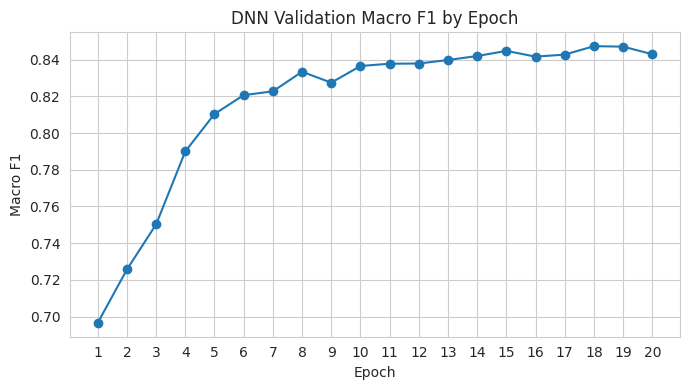

In [29]:
history_df = pd.DataFrame(history)

plt.figure(figsize=(7, 4))
plt.plot(history_df["epoch"], history_df["val_macro_f1"], marker="o")
plt.title("DNN Validation Macro F1 by Epoch")
plt.xlabel("Epoch")
plt.ylabel("Macro F1")
plt.xticks(history_df["epoch"])
plt.tight_layout()
plt.show()

The DNN validation Macro F1 improves steadily over epochs before stabilizing, which indicates that the model is learning meaningful class patterns without severe overfitting in the early stages. The smoother loss behavior after scaling confirms that neural networks are highly sensitive to feature magnitudes and benefit from model-specific preprocessing.

# 18. DNN Validation Evaluation
We evaluate the best DNN on the validation set using the same framework as the classical models.

{'Model': 'DNN', 'Accuracy': 0.8623197453024534, 'Macro Precision': 0.835827772239987, 'Macro Recall': 0.8525134292106196, 'Macro F1': 0.8429448156637381}

DNN - Classification Report
              precision    recall  f1-score   support

         Low       0.97      0.91      0.94     15982
      Medium       0.77      0.79      0.78      9638
        High       0.77      0.86      0.81      6418

    accuracy                           0.86     32038
   macro avg       0.84      0.85      0.84     32038
weighted avg       0.87      0.86      0.86     32038



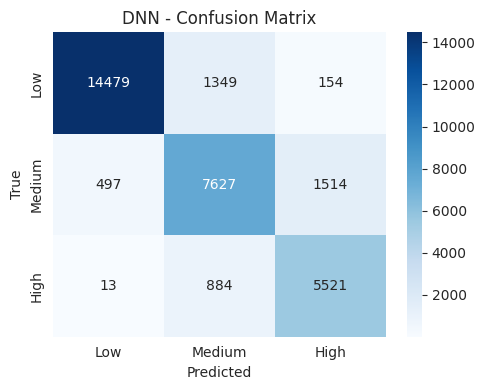

In [30]:
dnn_model.eval()
dnn_val_preds = []

with torch.no_grad():
    for X_batch, _ in val_loader:
        X_batch = X_batch.to(DEVICE)
        outputs = dnn_model(X_batch)
        preds = torch.argmax(outputs, dim=1)
        dnn_val_preds.extend(preds.cpu().numpy())

dnn_val_preds = np.array(dnn_val_preds)

dnn_results = evaluate_predictions("DNN", y_val, dnn_val_preds)
print(dnn_results)
print_model_report("DNN", y_val, dnn_val_preds)
plot_confusion("DNN", y_val, dnn_val_preds)

The DNN performs substantially better after feature standardization and achieves competitive results, though it remains slightly below XGBoost. The confusion matrix shows good identification of Low Risk events and improved recognition of Medium and High Risk cases compared with simpler baselines. This indicates that neural networks can learn useful nonlinear structure, but in this problem the tree-based boosting model is still more effective.

# 19. Compare All Models
We combine all validation metrics into one results table.

In [31]:
results_df = pd.DataFrame([
    logreg_results,
    rf_results,
    xgb_results,
    dnn_results
])

results_df = results_df.sort_values(by="Macro F1", ascending=False).reset_index(drop=True)
results_df

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1
0,XGBoost,0.8963,0.8798,0.8823,0.8809
1,DNN,0.8623,0.8358,0.8525,0.8429
2,Random Forest,0.7903,0.7560,0.7779,0.7631
3,Logistic Regression,0.4988,0.1663,0.3333,0.2219


# 20. Plot Validation Macro F1 Comparison
This provides a quick visual comparison of model performance.

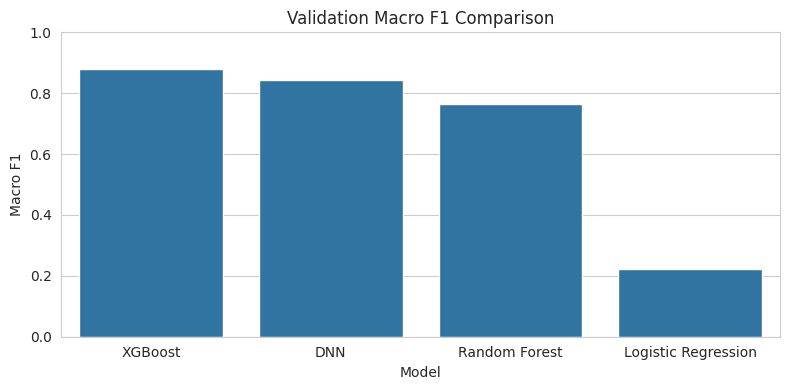

In [32]:
plt.figure(figsize=(8, 4))
sns.barplot(data=results_df, x="Model", y="Macro F1")
plt.title("Validation Macro F1 Comparison")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

The model comparison plot shows a clear ranking of performance: XGBoost performs best, followed by DNN, then Random Forest, while Logistic Regression performs worst. This suggests that the task is strongly nonlinear and benefits from models capable of learning complex feature interactions. It also shows that while the DNN is competitive, boosted trees remain the most effective approach for this engineered tabular dataset.

# 21. Tree-Based Feature Importance
We inspect the most important features from Random Forest and XGBoost.

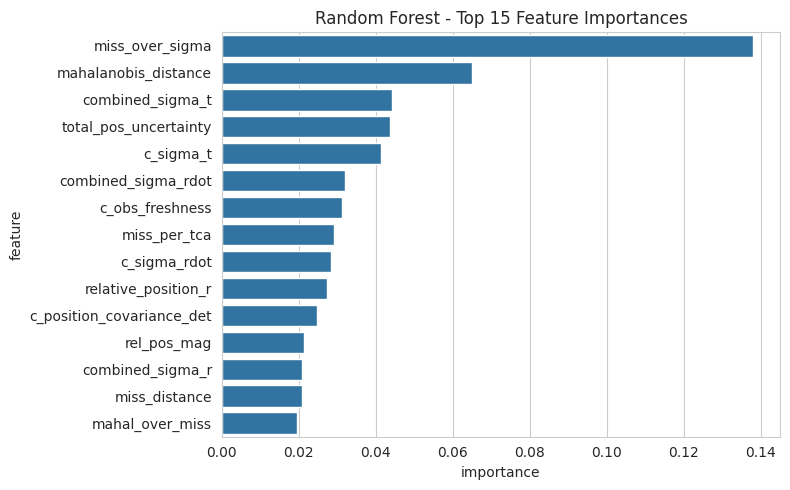

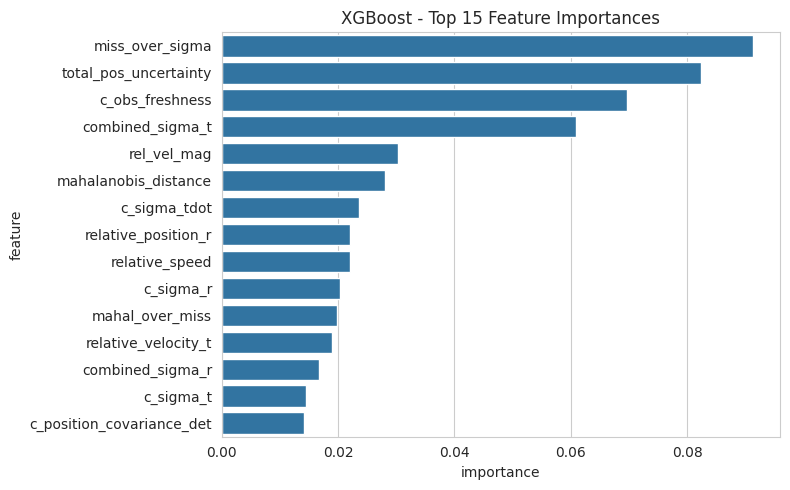

In [33]:
def plot_feature_importance(importances, feature_names, title, top_n=15):
    importance_df = pd.DataFrame({
        "feature": feature_names,
        "importance": importances
    }).sort_values(by="importance", ascending=False).head(top_n)

    plt.figure(figsize=(8, 5))
    sns.barplot(data=importance_df, x="importance", y="feature")
    plt.title(title)
    plt.tight_layout()
    plt.show()

plot_feature_importance(
    rf_model.feature_importances_,
    X_train.columns,
    "Random Forest - Top 15 Feature Importances"
)

plot_feature_importance(
    xgb_model.feature_importances_,
    X_train.columns,
    "XGBoost - Top 15 Feature Importances"
)

Random Forest feature importance

Inference:

The Random Forest importance plot shows that uncertainty-related and distance-normalized features, such as miss_over_sigma and mahalanobis_distance, play a major role in prediction. This indicates that collision risk is influenced not only by raw geometry, but also by how close the encounter is relative to positional uncertainty.


XGBoost feature importance

Inference:

The XGBoost importance plot highlights a similar pattern, with miss_over_sigma, total_pos_uncertainty, and related uncertainty-aware features ranking highly. This suggests that the most predictive signals are those combining encounter geometry with uncertainty and observation quality, which aligns well with the real-world nature of conjunction risk assessment.

# 22. Save Validation Comparison Table
We save the metrics table for the report and presentation.

In [34]:
results_df.to_csv(CONFIG["global"]["results_path"], index=False)
print("Saved:", CONFIG["global"]["results_path"])

Saved: /content/model_comparison_results.csv


# 23. Generate Final Test Predictions
We use the best validation model to produce test predictions.

Note:
If the test set has no labels, these are prediction outputs only.

In [35]:
best_model_name = results_df.iloc[0]["Model"]
print("Best validation model:", best_model_name)

Best validation model: XGBoost


In [36]:
if best_model_name == "Logistic Regression":
    test_preds = logreg_model.predict(X_test)

elif best_model_name == "Random Forest":
    test_preds = rf_model.predict(X_test)

elif best_model_name == "XGBoost":
    test_preds = xgb_model.predict(X_test)

else:
    X_test_np = X_test.values.astype(np.float32)
    X_test_tensor = torch.tensor(X_test_np, dtype=torch.float32).to(DEVICE)

    dnn_model.eval()
    with torch.no_grad():
        outputs = dnn_model(X_test_tensor)
        test_preds = torch.argmax(outputs, dim=1).cpu().numpy()

print("Total test predictions generated:", len(test_preds))

Total test predictions generated: 24484


# 24. Save Test Predictions
We save both numeric and readable class labels.

In [37]:
test_predictions_df = pd.DataFrame({
    "predicted_risk_label": test_preds
})

label_map = {
    0: "Low",
    1: "Medium",
    2: "High"
}

test_predictions_df["predicted_risk_level"] = test_predictions_df["predicted_risk_label"].map(label_map)

test_predictions_df.to_csv(CONFIG["global"]["predictions_path"], index=False)
print("Saved:", CONFIG["global"]["predictions_path"])

test_predictions_df.head()

Saved: /content/test_predictions.csv


,predicted_risk_label,predicted_risk_level
0,2,High
1,2,High
2,2,High
3,2,High
4,2,High


# 25. Final Summary
In this notebook, we:

- loaded the engineered train, validation, and test datasets
- trained four models under a centralized configuration framework
- evaluated all models on the same validation split
- compared results fairly using common metrics
- generated final predictions on the test set

This notebook serves as the main experimental benchmark for the classification stage of the project.

In [38]:
with open("/content/best_model_name.txt", "w") as f:
    f.write(best_model_name)

print("Saved: /content/best_model_name.txt")

Saved: /content/best_model_name.txt


In [39]:
import joblib
joblib.dump(xgb_model, "best_xgboost_model.pkl")

['best_xgboost_model.pkl']